In [ ]:
df = pd.read_csv('featured_data.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

df.head()

,Datetime,PJME_MW,hour,dayofweek,month,year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24
0,2002-01-08 01:00:00,29445.0,1,1,1,2002,0,0.258819,0.965926,0.5,0.866025,31187.0,26862.0,30393.0,33560.208333,4425.965952
1,2002-01-08 02:00:00,28670.0,2,1,1,2002,0,0.500000,0.866025,0.5,0.866025,29445.0,25976.0,29265.0,33672.458333,4256.159403
2,2002-01-08 03:00:00,28375.0,3,1,1,2002,0,0.707107,0.707107,0.5,0.866025,28670.0,25641.0,28357.0,33786.375000,4064.104959
3,2002-01-08 04:00:00,28542.0,4,1,1,2002,0,0.866025,0.500000,0.5,0.866025,28375.0,25666.0,27899.0,33906.208333,3851.076461
4,2002-01-08 05:00:00,29261.0,5,1,1,2002,0,0.965926,0.258819,0.5,0.866025,28542.0,26328.0,28057.0,34028.416667,3640.941409


In [ ]:
df.shape

(145198, 16)

In [ ]:
features = [
    'hour', 'dayofweek', 'month', 'year', 'is_weekend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_24', 'rolling_std_24'
]

target = 'PJME_MW'

X = df[features]
y = df[target]

In [ ]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = df['Datetime'].iloc[split_index:]

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return [name, mae, rmse, r2]

results = []

results.append(evaluate(y_test, lr_preds, "Linear Regression"))
results.append(evaluate(y_test, rf_preds, "Random Forest"))

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,777.974292,994.141797,0.976549
1,Random Forest,286.929996,396.382480,0.996272


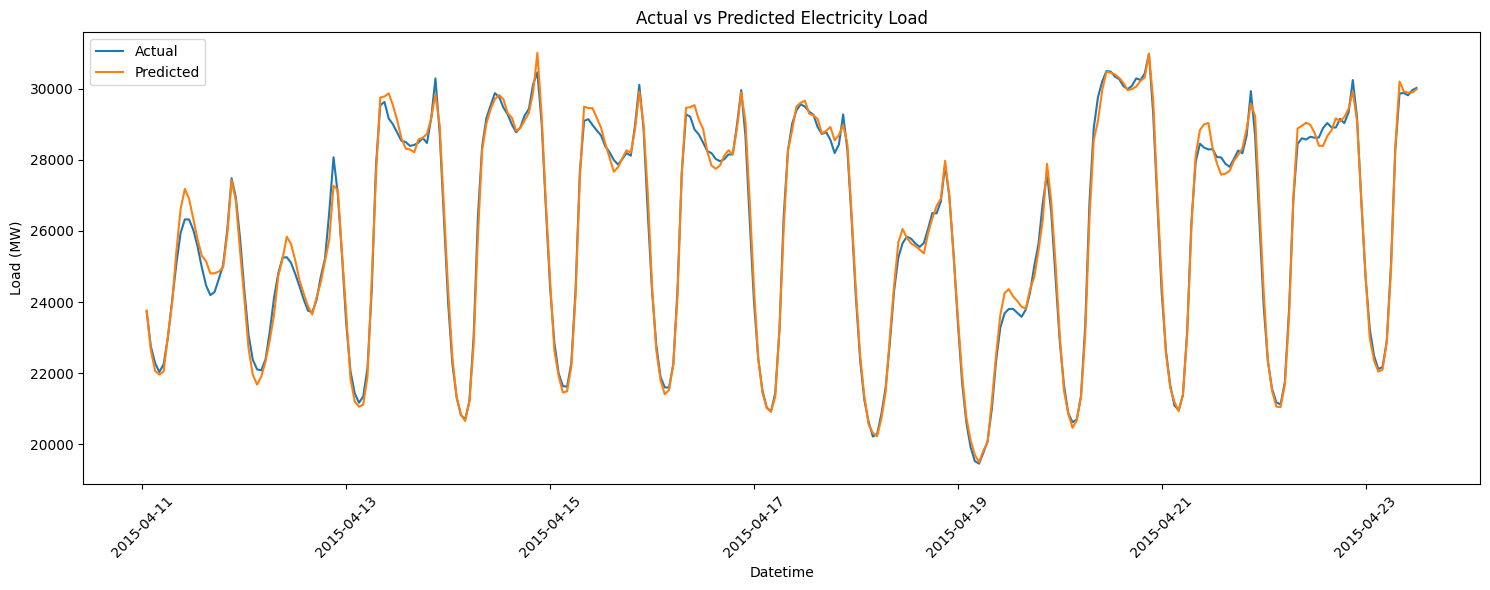

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(dates_test[:300], y_test.iloc[:300], label='Actual')
plt.plot(dates_test[:300], rf_preds[:300], label='Predicted')

plt.title("Actual vs Predicted Electricity Load")
plt.xlabel("Datetime")
plt.ylabel("Load (MW)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
9,lag_1,0.948794
6,hour_cos,0.025225
0,hour,0.010475
5,hour_sin,0.005441
13,rolling_std_24,0.002985
8,month_cos,0.001644
12,rolling_mean_24,0.001417
1,dayofweek,0.000935
10,lag_24,0.000861
4,is_weekend,0.000719


In [ ]:
results_df.to_csv('metrics_comparison.csv', index=False)